Environment Setup

In [10]:
import os
import yaml
import fiftyone as fo
import matplotlib.pyplot as plt
import fiftyone.zoo as foz
from pathlib import Path

Data Loading

In [11]:
# 1. Define absolute paths to avoid confusion
# We go up one level from 'notebooks' to get to the project root
ROOT_DIR = Path(os.getcwd()).parent 
DATASET_DIR = ROOT_DIR / "data" / "processed" / "yolo_dataset"
YAML_PATH = DATASET_DIR / "data.yaml"

# 2. Verify paths exist
if not YAML_PATH.exists():
    raise FileNotFoundError(f"Could not find data.yaml at {YAML_PATH}")

# 3. Load the dataset into FiftyOne
# We explicitly tell FiftyOne where the images and labels are for the 'val' split
dataset_name = "Weapon_Detection_EDA"

# Delete existing dataset if it exists to start fresh
if dataset_name in fo.list_datasets():
    fo.delete_dataset(dataset_name)

dataset = fo.Dataset.from_dir(
    dataset_dir=str(DATASET_DIR),
    dataset_type=fo.types.YOLOv5Dataset,
    overwrite=True,
    yaml_path=str(YAML_PATH),
    name=dataset_name,
    split="train" 
)

print(f"Total samples loaded: {len(dataset)}")
print(f"Classes found: {dataset.default_classes}")


 100% |█████████████| 36062/36062 [1.6m elapsed, 0s remaining, 400.1 samples/s]      
Total samples loaded: 36062
Classes found: ['Weapon', 'Person', 'Confuser']


Class Distribution Analysis

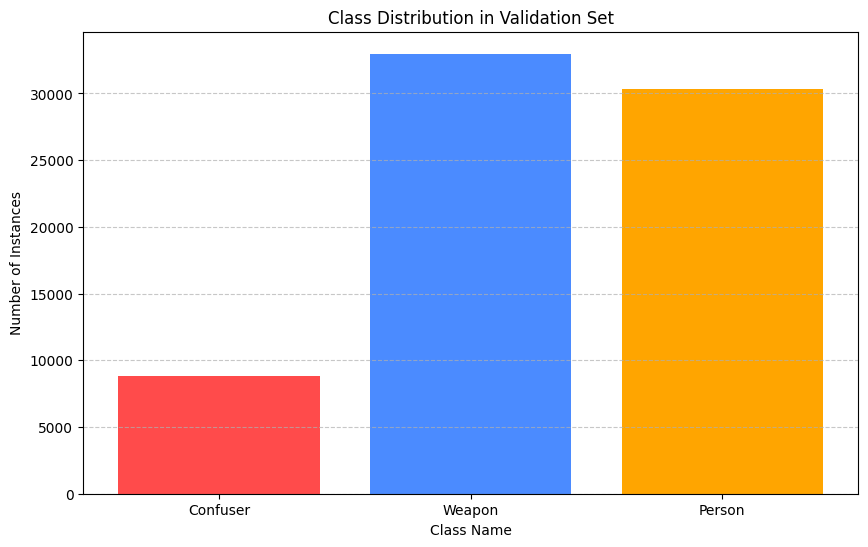

 Confuser: 8803 instances
 Weapon: 32976 instances
 Person: 30327 instances


In [12]:
# Calculate class counts
counts = dataset.count_values("ground_truth.detections.label")

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(counts.keys(), counts.values(), color=['#FF4B4B', '#4B8BFF', '#FFA500'])
plt.title("Class Distribution in Validation Set")
plt.xlabel("Class Name")
plt.ylabel("Number of Instances")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

for label, count in counts.items():
    print(f" {label}: {count} instances")


In [14]:
# 1. Launch the interactive session
session = fo.launch_app(dataset, port=5151)

# 2. Add some helpful views
print("Dashboard Suggestions:")
print("- Click 'Labels' to filter by Weapon, Person, or Confuser.")
print("- Use the 'Grid' settings to change image size.")
print("- Click on any image to see the bounding boxes and labels.")

# Keep the session alive if running in a script (not needed in Jupyter usually)
# session.wait()




███████╗██╗███████╗████████╗██╗   ██╗ ██████╗ ███╗   ██╗███████╗
██╔════╝██║██╔════╝╚══██╔══╝╚██╗ ██╔╝██╔═══██╗████╗  ██║██╔════╝
█████╗  ██║█████╗     ██║    ╚████╔╝ ██║   ██║██╔██╗ ██║█████╗
██╔══╝  ██║██╔══╝     ██║     ╚██╔╝  ██║   ██║██║╚██╗██║██╔══╝
██║     ██║██║        ██║      ██║   ╚██████╔╝██║ ╚████║███████╗
╚═╝     ╚═╝╚═╝        ╚═╝      ╚═╝    ╚═════╝ ╚═╝  ╚═══╝╚══════╝ v1.15.0

🤖  Ask the Docs Agent       https://docs.voxel51.com
🚀  Getting Started Guides   https://docs.voxel51.com/getting_started
💬  Join the Community       https://community.voxel51.com
🎓  Book a Workshop          https://voxel51.com/workshops

Dashboard Suggestions:
- Click 'Labels' to filter by Weapon, Person, or Confuser.
- Use the 'Grid' settings to change image size.
- Click on any image to see the bounding boxes and labels.
